In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

### new

In [2]:
adata_human = sc.read_h5ad("/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0514_rename_level3/output_allhuman/work_0514/scPoli_concat_level3_marker_all_metadata.h5ad")
adata_mouse = sc.read_h5ad("/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0514_rename_level3/output_mouse/work_0514/scPoli_concat_level3_marker_allmouse.h5ad")

In [3]:
adata_human.obs['symptoms'].value_counts()

symptoms
Atherosclerosis        432104
AAA                    175546
Healthy                107761
TAA                     83086
Atherosclerosis,ISR     78162
ATAA                    38670
AD                      33109
IAA                     22994
not stated              19533
MF                      16429
CBT                      8305
Name: count, dtype: int64

In [4]:
adata_healthy = adata_human[adata_human.obs['symptoms'] == 'Healthy'].copy()
adata_healthy

AnnData object with n_obs × n_vars = 107761 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'cell_type_level1_corrected', 'cell_type_level2', 'cell_type_level3', 'Plaque_type'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [5]:
adata_healthy.obs['sample'].value_counts()

sample
S2             26323
S1             17685
S3             15783
GSE226492_2    12763
GSE226492_3    10372
GSE226492_1     8998
GSE155468_3     3907
GSE166676_6     3079
GSE155468_1     3073
GSE166676_5     1877
GSE155468_2     1193
GSE143921_2     1159
GSE143921_3     1034
GSE143921_1      515
Name: count, dtype: int64

Human symptoms:
condition
Atherosclerosis        432104
AAA                    175546
Healthy                107761
TAA                     83086
Atherosclerosis,ISR     78162
ATAA                    38670
AD                      33109
IAA                     22994
not stated              19533
MF                      16429
CBT                      8305
Name: count, dtype: int64

Human Plaque_type cleaned:
plaque_type_clean
unknown     803107
unstable    151797
stable       60795
Name: count, dtype: int64

Mouse symptoms:
condition
Atherosclerosis    288393
AAA                143047
Healthy             65582
IMH                 44376
AAD                 16813
atherosclerosis      1947
RA                   1418
Name: count, dtype: int64


/tmp/ipykernel_1721636/3400086344.py:129: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_obs = pd.concat(



三个分布的细胞数:
distribution          condition_plot 
Human health/disease  Disease            907938
                      Healthy            107761
Human plaque          Plaque_Stable       60795
                      Plaque_Unstable    151797
Mouse health/disease  Disease            495994
                      Healthy             65582
dtype: int64


/tmp/ipykernel_1721636/3400086344.py:148: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  all_obs
/tmp/ipykernel_1721636/3400086344.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_df



展示的 cell types:
['T cell', 'Macrophage', 'Fibroblast', 'Smooth muscle cell', 'B cell', 'Neutrophil', 'Endothelial cell', 'Natural killer cell', 'Monocyte', 'Dendritic cell', 'Pericyte', 'Erythrocyte/Erythroid']

比例差异表:
condition_plot          distribution cell_type_level1_corrected   Disease  \
0               Human health/disease                     B cell  0.097978   
1               Human health/disease             Dendritic cell  0.036477   
2               Human health/disease           Endothelial cell  0.059393   
3               Human health/disease      Erythrocyte/Erythroid  0.004306   
4               Human health/disease                 Fibroblast  0.058095   
5               Human health/disease                 Macrophage  0.099361   
6               Human health/disease                   Monocyte  0.035726   
7               Human health/disease        Natural killer cell  0.056655   
8               Human health/disease                 Neutrophil  0.089320   
9         

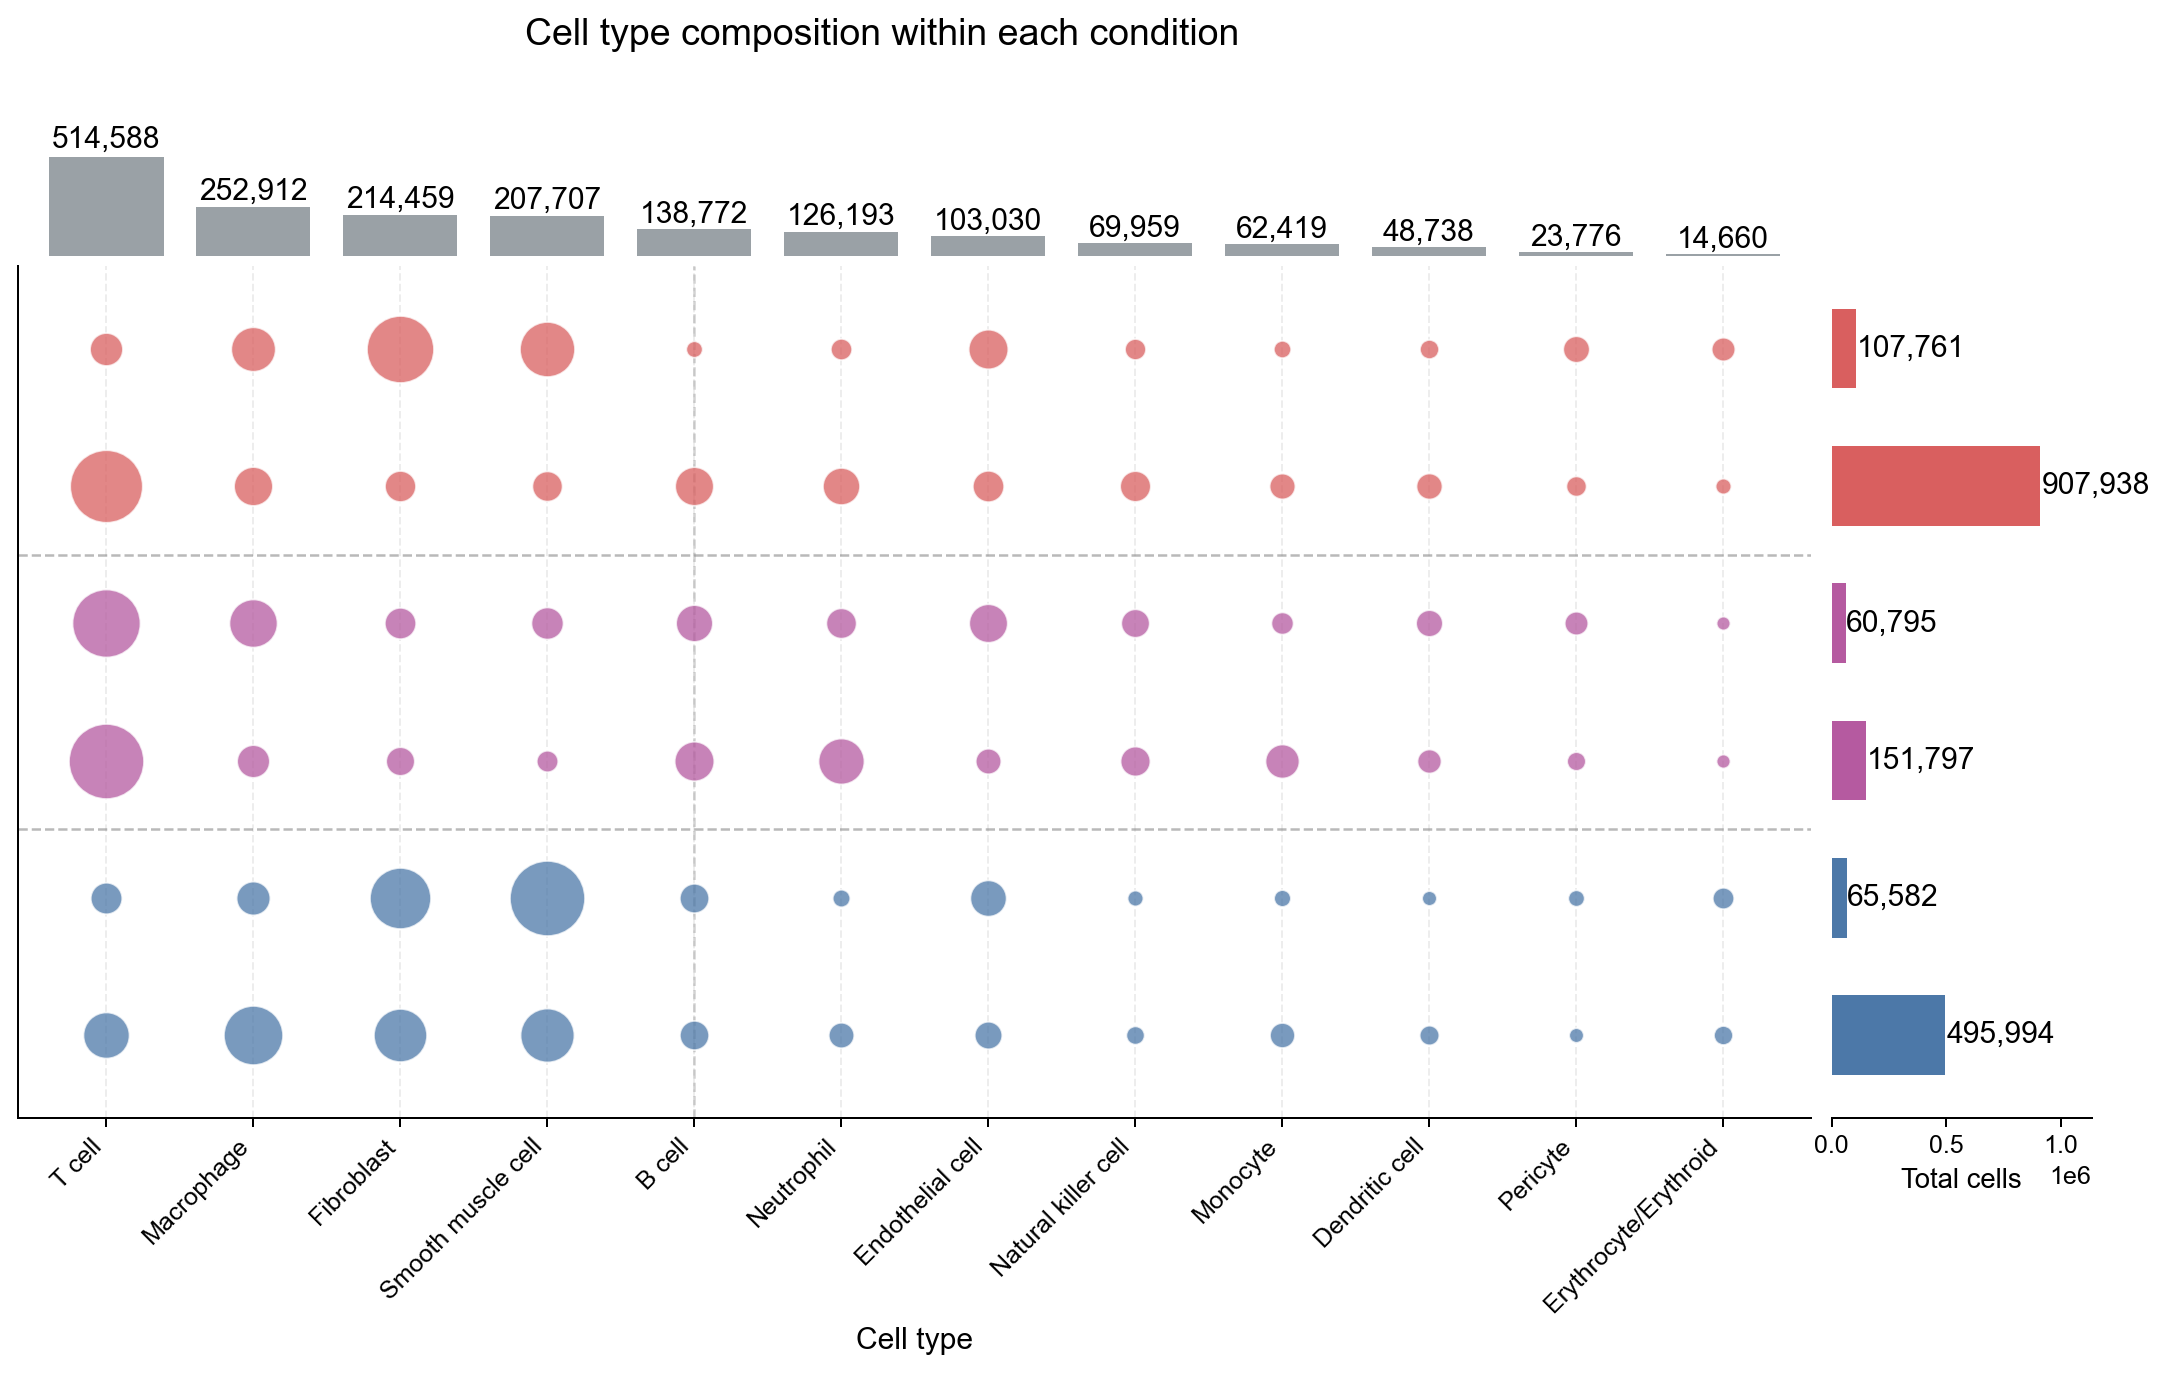

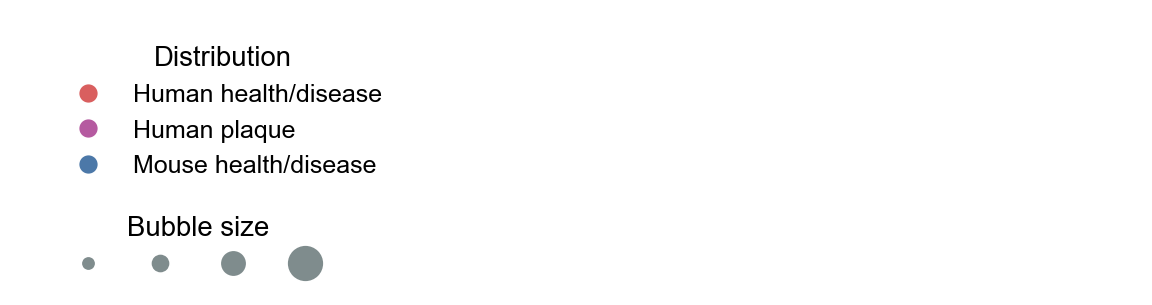

绘图完成。
比例差异表已保存为: celltype_proportion_difference.csv


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# =========================================================
# 0. 参数设置
# =========================================================
plaque_col = 'Plaque_type'
celltype_col = 'cell_type_level1_corrected'
condition_col = 'symptoms'

healthy_name = 'Healthy'
disease_name = 'Disease'

top_n_celltypes = 12
min_bubble = 30
max_bubble = 900

colors = {
    'Human health/disease': '#d95f5f',
    'Human plaque': '#b55aa0',
    'Mouse health/disease': '#4c78a8'
}

label_map = {
    'Healthy': 'Healthy',
    'Disease': 'Disease',
    'Plaque_Stable': 'Stable plaque',
    'Plaque_Unstable': 'Unstable plaque'
}

row_order = [
    ('Human health/disease', 'Healthy'),
    ('Human health/disease', 'Disease'),
    ('Human plaque', 'Plaque_Stable'),
    ('Human plaque', 'Plaque_Unstable'),
    ('Mouse health/disease', 'Healthy'),
    ('Mouse health/disease', 'Disease')
]

# =========================================================
# 1. 检查列
# =========================================================
for col in [condition_col, plaque_col, celltype_col]:
    if col not in adata_human.obs.columns:
        raise ValueError(f"Human 数据缺少列: {col}")

for col in [condition_col, celltype_col]:
    if col not in adata_mouse.obs.columns:
        raise ValueError(f"Mouse 数据缺少列: {col}")

# =========================================================
# 2. 整理 human / mouse obs
# =========================================================
human = adata_human.obs.copy()
mouse = adata_mouse.obs.copy()

human['species'] = 'Human'
mouse['species'] = 'Mouse'

human['condition'] = human[condition_col].astype(str).str.strip()
mouse['condition'] = mouse[condition_col].astype(str).str.strip()

human['condition'] = human['condition'].replace({
    'Atherosclerosis+Diabetes': 'Atherosclerosis'
})

mouse['condition'] = mouse['condition'].replace({
    'Atherosclerosis+Diabetes': 'Atherosclerosis'
})

human['plaque_type_clean'] = (
    human[plaque_col]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace('-', '_', regex=False)
    .str.replace(' ', '_', regex=False)
)

plaque_map = {
    'stable': 'Plaque_Stable',
    'stable_plaque': 'Plaque_Stable',
    'plaque_stable': 'Plaque_Stable',
    'unstable': 'Plaque_Unstable',
    'unstable_plaque': 'Plaque_Unstable',
    'plaque_unstable': 'Plaque_Unstable'
}

print("Human symptoms:")
print(human['condition'].value_counts(dropna=False))

print("\nHuman Plaque_type cleaned:")
print(human['plaque_type_clean'].value_counts(dropna=False).head(30))

print("\nMouse symptoms:")
print(mouse['condition'].value_counts(dropna=False))

# =========================================================
# 3. 构建三个独立比较分布
# =========================================================

# 3.1 Human Healthy vs Disease
human_hd = human.copy()
human_hd['distribution'] = 'Human health/disease'
human_hd['condition_plot'] = np.where(
    human_hd['condition'].eq(healthy_name),
    'Healthy',
    disease_name
)

# 3.2 Human Stable plaque vs Unstable plaque
human_plaque = human[human['plaque_type_clean'].isin(plaque_map)].copy()
human_plaque['distribution'] = 'Human plaque'
human_plaque['condition_plot'] = human_plaque['plaque_type_clean'].map(plaque_map)

# 3.3 Mouse Healthy vs Disease
mouse_hd = mouse.copy()
mouse_hd['distribution'] = 'Mouse health/disease'
mouse_hd['condition_plot'] = np.where(
    mouse_hd['condition'].eq(healthy_name),
    'Healthy',
    disease_name
)

all_obs = pd.concat(
    [human_hd, human_plaque, mouse_hd],
    axis=0
)

if all_obs.empty:
    raise ValueError("筛选后没有细胞，请检查 symptoms 或 Plaque_type。")

print("\n三个分布的细胞数:")
print(
    all_obs
    .groupby(['distribution', 'condition_plot'])
    .size()
)

# =========================================================
# 4. 统计 count 和每个 condition 内部比例
# =========================================================
count_df = (
    all_obs
    .groupby(['distribution', 'condition_plot', celltype_col])
    .size()
    .reset_index(name='cell_count')
)

group_total_df = (
    all_obs
    .groupby(['distribution', 'condition_plot'])
    .size()
    .reset_index(name='group_total')
)

count_df = count_df.merge(
    group_total_df,
    on=['distribution', 'condition_plot'],
    how='left'
)

count_df['proportion'] = count_df['cell_count'] / count_df['group_total']

# =========================================================
# 5. 选择展示的 cell types
# =========================================================
celltype_total = (
    count_df
    .groupby(celltype_col)['cell_count']
    .sum()
    .sort_values(ascending=False)
)

selected_celltypes = celltype_total.index.tolist()[:top_n_celltypes]

print("\n展示的 cell types:")
print(selected_celltypes)

# =========================================================
# 6. 补全组合并重新计算每个 condition 内部比例
# =========================================================
full_index = pd.MultiIndex.from_tuples(
    [
        (distribution, condition, celltype)
        for distribution, condition in row_order
        for celltype in selected_celltypes
    ],
    names=['distribution', 'condition_plot', celltype_col]
)

plot_df = (
    count_df
    .set_index(['distribution', 'condition_plot', celltype_col])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

plot_df = plot_df.drop(
    columns=['group_total', 'proportion'],
    errors='ignore'
)

plot_df = plot_df.merge(
    group_total_df,
    on=['distribution', 'condition_plot'],
    how='left'
)

plot_df['proportion'] = plot_df['cell_count'] / plot_df['group_total']
plot_df['proportion'] = plot_df['proportion'].fillna(0)

# =========================================================
# 7. 用每个 condition 内部比例设置气泡大小
# =========================================================
max_prop = max(plot_df['proportion'].max(), 1e-9)

plot_df['bubble_size'] = (
    min_bubble +
    plot_df['proportion'] / max_prop * (max_bubble - min_bubble)
)

plot_df['alpha'] = 0.75

# =========================================================
# 8. 计算比例差异表，方便直接比较
# =========================================================
wide_prop = (
    plot_df
    .pivot_table(
        index=['distribution', celltype_col],
        columns='condition_plot',
        values='proportion',
        fill_value=0
    )
    .reset_index()
)

if {'Healthy', 'Disease'}.issubset(wide_prop.columns):
    wide_prop['Disease_minus_Healthy'] = (
        wide_prop['Disease'] - wide_prop['Healthy']
    )

if {'Plaque_Stable', 'Plaque_Unstable'}.issubset(wide_prop.columns):
    wide_prop['Unstable_minus_Stable'] = (
        wide_prop['Plaque_Unstable'] - wide_prop['Plaque_Stable']
    )

print("\n比例差异表:")
print(wide_prop)

wide_prop.to_csv(
    "celltype_proportion_difference.csv",
    index=False
)

# =========================================================
# 9. 美化绘图：主图
# =========================================================
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 180

fig = plt.figure(figsize=(16, 8.2))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1.05, 7], width_ratios=[10, 1.45], hspace=0.02, wspace=0.02)

ax_top = fig.add_subplot(gs[0, 0])
ax_bubble = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_bubble)

x_positions = {ct: i for i, ct in enumerate(selected_celltypes)}
row_to_y = {row: len(row_order) - 1 - i for i, row in enumerate(row_order)}
y_labels = [f"{distribution}\n{label_map.get(condition, condition)}" for distribution, condition in row_order]

top_bar_df = plot_df.groupby(celltype_col)['cell_count'].sum().reindex(selected_celltypes)

ax_top.bar(np.arange(len(selected_celltypes)), top_bar_df.values, color='#9aa1a6', width=0.78)
ax_top.set_xlim(-0.6, len(selected_celltypes) - 0.4)
ax_top.set_xticks([])
ax_top.set_yticks([])
ax_top.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

for i, v in enumerate(top_bar_df.values):
    ax_top.text(i, v * 1.03, f'{int(v):,}', ha='center', va='bottom', fontsize=12, rotation=0)

ax_top.set_ylim(0, top_bar_df.max() * 1.28)

for spine in ['top', 'right', 'left', 'bottom']:
    ax_top.spines[spine].set_visible(False)

for _, row in plot_df.iterrows():
    row_key = (row['distribution'], row['condition_plot'])
    ax_bubble.scatter(x_positions[row[celltype_col]], row_to_y[row_key], s=row['bubble_size'], color=colors[row['distribution']], alpha=row['alpha'], edgecolor='white', linewidth=0.7, zorder=3)

ax_bubble.set_xlim(-0.6, len(selected_celltypes) - 0.4)
ax_bubble.set_ylim(-0.6, len(row_order) - 0.4)
ax_bubble.set_xticks(np.arange(len(selected_celltypes)))
ax_bubble.set_xticklabels(selected_celltypes, rotation=45, ha='right', fontsize=10)
ax_bubble.set_yticks(np.arange(len(row_order)))
ax_bubble.set_yticklabels(list(reversed(y_labels)), fontsize=10)
ax_bubble.set_xlabel('Cell type', fontsize=12)
ax_bubble.set_ylabel('', fontsize=12)
ax_bubble.grid(axis='both', linestyle='--', alpha=0.22, zorder=0)

for spine in ['top', 'right']:
    ax_bubble.spines[spine].set_visible(False)

ax_bubble.axhline(y=3.5, linestyle='--', color='grey', alpha=0.55, linewidth=1)
ax_bubble.axhline(y=1.5, linestyle='--', color='grey', alpha=0.55, linewidth=1)

if len(selected_celltypes) > 4:
    ax_bubble.axvline(x=4, linestyle='--', color='grey', alpha=0.35, linewidth=1)

group_total_plot = group_total_df.copy()
group_total_plot['row_key'] = list(zip(group_total_plot['distribution'], group_total_plot['condition_plot']))
group_total_plot = group_total_plot[group_total_plot['row_key'].isin(row_order)]
group_total_plot['y'] = group_total_plot['row_key'].map(row_to_y)

ax_right.barh(group_total_plot['y'], group_total_plot['group_total'], color=[colors[d] for d in group_total_plot['distribution']], height=0.58)
ax_right.set_xlabel('Total cells', fontsize=11)
ax_right.set_yticks([])
ax_right.tick_params(axis='y', left=False, labelleft=False)
ax_right.margins(x=0.03)

for y, v in zip(group_total_plot['y'], group_total_plot['group_total']):
    ax_right.text(v * 1.01, y, f'{int(v):,}', va='center', ha='left', fontsize=12)

ax_right.set_xlim(0, group_total_plot['group_total'].max() * 1.25)

for spine in ['top', 'right', 'left']:
    ax_right.spines[spine].set_visible(False)

fig.suptitle('Cell type composition within each condition', fontsize=15, y=0.985)
plt.subplots_adjust(left=0.20, right=0.92, top=0.91, bottom=0.24)
plt.show()

# =========================================================
# 10. 单独画图例
# =========================================================
fig_leg, ax_leg = plt.subplots(figsize=(6.5, 1.8), dpi=180)
ax_leg.axis('off')

dist_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[d], markeredgecolor='white', markeredgewidth=0.7, markersize=8, label=d) for d in colors]
size_breaks = [0.05, 0.10, 0.20, 0.40]
size_breaks = [x for x in size_breaks if x <= max_prop]
if len(size_breaks) == 0:
    size_breaks = [max_prop]

legend_size_scale = 0.5
size_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#7f8c8d', markeredgecolor='white', markeredgewidth=0.7, markersize=np.sqrt(min_bubble + s / max_prop * (max_bubble - min_bubble)) * legend_size_scale, label='') for s in size_breaks]

legend1 = ax_leg.legend(handles=dist_handles, title='Distribution', loc='upper left', bbox_to_anchor=(0.02, 0.98), frameon=False, fontsize=10, title_fontsize=11)
ax_leg.add_artist(legend1)

ax_leg.legend(handles=size_handles, title='Bubble size', loc='upper left', bbox_to_anchor=(0.02, 0.30), frameon=False, ncol=len(size_handles), handletextpad=0.1, columnspacing=0.8, fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()

print("绘图完成。")
print("比例差异表已保存为: celltype_proportion_difference.csv")

Human symptoms:
condition
Atherosclerosis        432104
AAA                    175546
Healthy                107761
TAA                     83086
Atherosclerosis,ISR     78162
ATAA                    38670
AD                      33109
IAA                     22994
not stated              19533
MF                      16429
CBT                      8305
Name: count, dtype: int64

Human Plaque_type cleaned:
plaque_type_clean
unknown     803107
unstable    151797
stable       60795
Name: count, dtype: int64

Mouse symptoms:
condition
Atherosclerosis    288393
AAA                143047
Healthy             65582
IMH                 44376
AAD                 16813
atherosclerosis      1947
RA                   1418
Name: count, dtype: int64


/tmp/ipykernel_490390/3647251227.py:129: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_obs = pd.concat(



三个分布的细胞数:
distribution          condition_plot 
Human health/disease  Disease            907938
                      Healthy            107761
Human plaque          Plaque_Stable       60795
                      Plaque_Unstable    151797
Mouse health/disease  Disease            495994
                      Healthy             65582
dtype: int64


/tmp/ipykernel_490390/3647251227.py:148: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  all_obs
/tmp/ipykernel_490390/3647251227.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_df



展示的 cell types:
['T cell', 'Macrophage', 'Fibroblast', 'Smooth muscle cell', 'B cell', 'Neutrophil', 'Endothelial cell', 'Natural killer cell', 'Monocyte', 'Dendritic cell', 'Pericyte', 'Erythrocyte/Erythroid']

比例差异表:
condition_plot          distribution cell_type_level1_corrected   Disease  \
0               Human health/disease                     B cell  0.097978   
1               Human health/disease             Dendritic cell  0.036477   
2               Human health/disease           Endothelial cell  0.059393   
3               Human health/disease      Erythrocyte/Erythroid  0.004306   
4               Human health/disease                 Fibroblast  0.058095   
5               Human health/disease                 Macrophage  0.099361   
6               Human health/disease                   Monocyte  0.035726   
7               Human health/disease        Natural killer cell  0.056655   
8               Human health/disease                 Neutrophil  0.089320   
9         

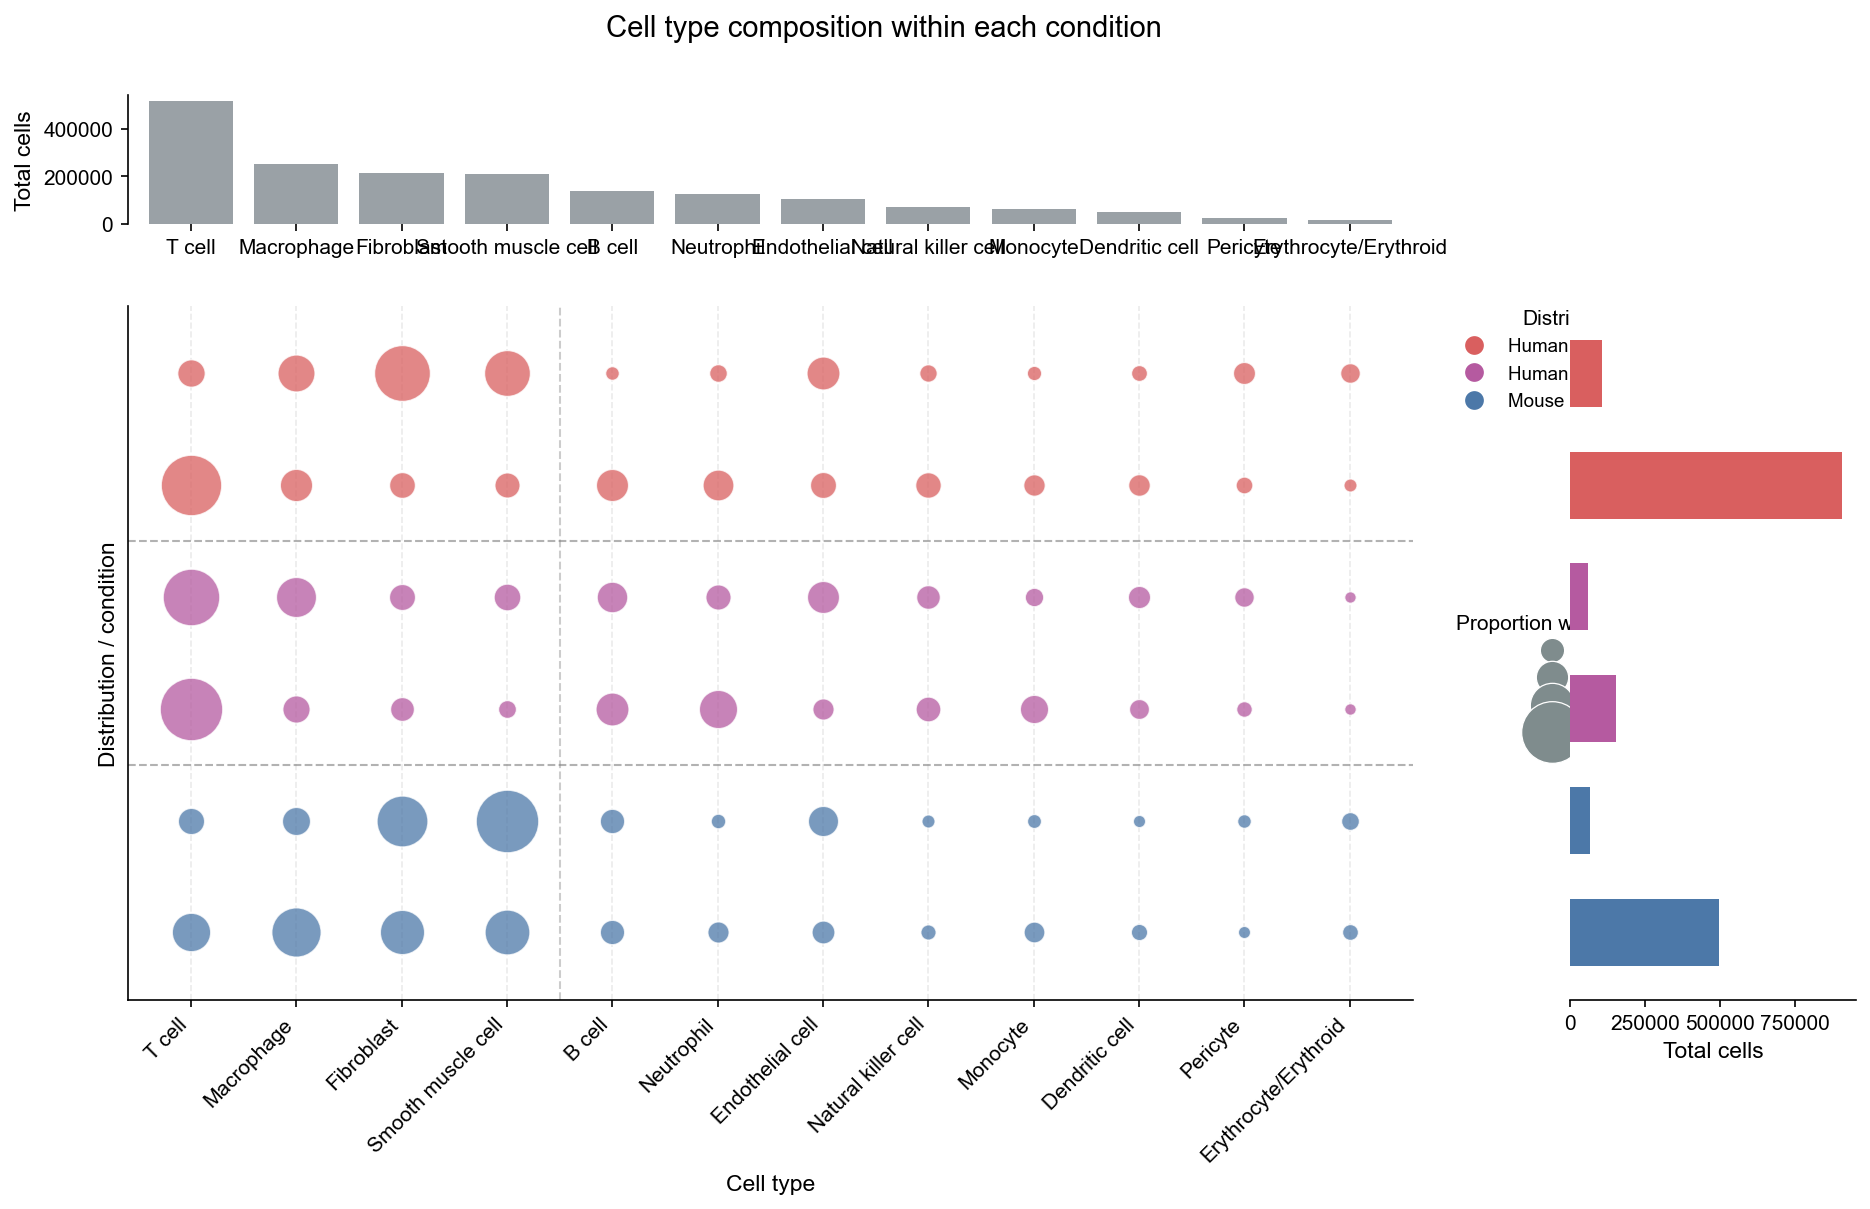

绘图完成。
比例差异表已保存为: celltype_proportion_difference.csv


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# =========================================================
# 0. 参数设置
# =========================================================
plaque_col = 'Plaque_type'
celltype_col = 'cell_type_level1_corrected'
condition_col = 'symptoms'

healthy_name = 'Healthy'
disease_name = 'Disease'

top_n_celltypes = 12
min_bubble = 30
max_bubble = 900

colors = {
    'Human health/disease': '#d95f5f',
    'Human plaque': '#b55aa0',
    'Mouse health/disease': '#4c78a8'
}

label_map = {
    'Healthy': 'Healthy',
    'Disease': 'Disease',
    'Plaque_Stable': 'Stable plaque',
    'Plaque_Unstable': 'Unstable plaque'
}

row_order = [
    ('Human health/disease', 'Healthy'),
    ('Human health/disease', 'Disease'),
    ('Human plaque', 'Plaque_Stable'),
    ('Human plaque', 'Plaque_Unstable'),
    ('Mouse health/disease', 'Healthy'),
    ('Mouse health/disease', 'Disease')
]

# =========================================================
# 1. 检查列
# =========================================================
for col in [condition_col, plaque_col, celltype_col]:
    if col not in adata_human.obs.columns:
        raise ValueError(f"Human 数据缺少列: {col}")

for col in [condition_col, celltype_col]:
    if col not in adata_mouse.obs.columns:
        raise ValueError(f"Mouse 数据缺少列: {col}")

# =========================================================
# 2. 整理 human / mouse obs
# =========================================================
human = adata_human.obs.copy()
mouse = adata_mouse.obs.copy()

human['species'] = 'Human'
mouse['species'] = 'Mouse'

human['condition'] = human[condition_col].astype(str).str.strip()
mouse['condition'] = mouse[condition_col].astype(str).str.strip()

human['condition'] = human['condition'].replace({
    'Atherosclerosis+Diabetes': 'Atherosclerosis'
})

mouse['condition'] = mouse['condition'].replace({
    'Atherosclerosis+Diabetes': 'Atherosclerosis'
})

human['plaque_type_clean'] = (
    human[plaque_col]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace('-', '_', regex=False)
    .str.replace(' ', '_', regex=False)
)

plaque_map = {
    'stable': 'Plaque_Stable',
    'stable_plaque': 'Plaque_Stable',
    'plaque_stable': 'Plaque_Stable',
    'unstable': 'Plaque_Unstable',
    'unstable_plaque': 'Plaque_Unstable',
    'plaque_unstable': 'Plaque_Unstable'
}

print("Human symptoms:")
print(human['condition'].value_counts(dropna=False))

print("\nHuman Plaque_type cleaned:")
print(human['plaque_type_clean'].value_counts(dropna=False).head(30))

print("\nMouse symptoms:")
print(mouse['condition'].value_counts(dropna=False))

# =========================================================
# 3. 构建三个独立比较分布
# =========================================================

# 3.1 Human Healthy vs Disease
human_hd = human.copy()
human_hd['distribution'] = 'Human health/disease'
human_hd['condition_plot'] = np.where(
    human_hd['condition'].eq(healthy_name),
    'Healthy',
    disease_name
)

# 3.2 Human Stable plaque vs Unstable plaque
human_plaque = human[human['plaque_type_clean'].isin(plaque_map)].copy()
human_plaque['distribution'] = 'Human plaque'
human_plaque['condition_plot'] = human_plaque['plaque_type_clean'].map(plaque_map)

# 3.3 Mouse Healthy vs Disease
mouse_hd = mouse.copy()
mouse_hd['distribution'] = 'Mouse health/disease'
mouse_hd['condition_plot'] = np.where(
    mouse_hd['condition'].eq(healthy_name),
    'Healthy',
    disease_name
)

all_obs = pd.concat(
    [human_hd, human_plaque, mouse_hd],
    axis=0
)

if all_obs.empty:
    raise ValueError("筛选后没有细胞，请检查 symptoms 或 Plaque_type。")

print("\n三个分布的细胞数:")
print(
    all_obs
    .groupby(['distribution', 'condition_plot'])
    .size()
)

# =========================================================
# 4. 统计 count 和每个 condition 内部比例
# =========================================================
count_df = (
    all_obs
    .groupby(['distribution', 'condition_plot', celltype_col])
    .size()
    .reset_index(name='cell_count')
)

group_total_df = (
    all_obs
    .groupby(['distribution', 'condition_plot'])
    .size()
    .reset_index(name='group_total')
)

count_df = count_df.merge(
    group_total_df,
    on=['distribution', 'condition_plot'],
    how='left'
)

count_df['proportion'] = count_df['cell_count'] / count_df['group_total']

# =========================================================
# 5. 选择展示的 cell types
# =========================================================
celltype_total = (
    count_df
    .groupby(celltype_col)['cell_count']
    .sum()
    .sort_values(ascending=False)
)

selected_celltypes = celltype_total.index.tolist()[:top_n_celltypes]

print("\n展示的 cell types:")
print(selected_celltypes)

# =========================================================
# 6. 补全组合并重新计算每个 condition 内部比例
# =========================================================
full_index = pd.MultiIndex.from_tuples(
    [
        (distribution, condition, celltype)
        for distribution, condition in row_order
        for celltype in selected_celltypes
    ],
    names=['distribution', 'condition_plot', celltype_col]
)

plot_df = (
    count_df
    .set_index(['distribution', 'condition_plot', celltype_col])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

plot_df = plot_df.drop(
    columns=['group_total', 'proportion'],
    errors='ignore'
)

plot_df = plot_df.merge(
    group_total_df,
    on=['distribution', 'condition_plot'],
    how='left'
)

plot_df['proportion'] = plot_df['cell_count'] / plot_df['group_total']
plot_df['proportion'] = plot_df['proportion'].fillna(0)

# =========================================================
# 7. 用每个 condition 内部比例设置气泡大小
# =========================================================
max_prop = max(plot_df['proportion'].max(), 1e-9)

plot_df['bubble_size'] = (
    min_bubble +
    plot_df['proportion'] / max_prop * (max_bubble - min_bubble)
)

plot_df['alpha'] = 0.75

# =========================================================
# 8. 计算比例差异表，方便直接比较
# =========================================================
wide_prop = (
    plot_df
    .pivot_table(
        index=['distribution', celltype_col],
        columns='condition_plot',
        values='proportion',
        fill_value=0
    )
    .reset_index()
)

if {'Healthy', 'Disease'}.issubset(wide_prop.columns):
    wide_prop['Disease_minus_Healthy'] = (
        wide_prop['Disease'] - wide_prop['Healthy']
    )

if {'Plaque_Stable', 'Plaque_Unstable'}.issubset(wide_prop.columns):
    wide_prop['Unstable_minus_Stable'] = (
        wide_prop['Plaque_Unstable'] - wide_prop['Plaque_Stable']
    )

print("\n比例差异表:")
print(wide_prop)

wide_prop.to_csv(
    "celltype_proportion_difference.csv",
    index=False
)

# =========================================================
# 9. 绘图
# =========================================================
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

fig = plt.figure(figsize=(18, 9))

gs = GridSpec(
    2, 2,
    figure=fig,
    height_ratios=[1.3, 7],
    width_ratios=[9, 2]
)

ax_top = fig.add_subplot(gs[0, 0])
ax_bubble = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_bubble)

x_positions = {
    ct: i for i, ct in enumerate(selected_celltypes)
}

row_to_y = {
    row: len(row_order) - 1 - i
    for i, row in enumerate(row_order)
}

y_labels = [
    f"{distribution}\n{label_map.get(condition, condition)}"
    for distribution, condition in row_order
]

# 顶部 bar：每个 cell type 总细胞数
top_bar_df = (
    plot_df
    .groupby(celltype_col)['cell_count']
    .sum()
    .reindex(selected_celltypes)
)

ax_top.bar(
    np.arange(len(selected_celltypes)),
    top_bar_df.values,
    color='#9aa1a6',
    width=0.8
)

ax_top.set_ylabel('Total cells', fontsize=11)
ax_top.set_xticks([])

for spine in ['top', 'right', 'bottom']:
    ax_top.spines[spine].set_visible(False)

# 气泡图
for _, row in plot_df.iterrows():
    row_key = (row['distribution'], row['condition_plot'])

    ax_bubble.scatter(
        x_positions[row[celltype_col]],
        row_to_y[row_key],
        s=row['bubble_size'],
        color=colors[row['distribution']],
        alpha=row['alpha'],
        edgecolor='white',
        linewidth=0.6,
        zorder=3
    )

ax_bubble.set_xlim(-0.6, len(selected_celltypes) - 0.4)
ax_bubble.set_ylim(-0.6, len(row_order) - 0.4)

ax_bubble.set_xticks(np.arange(len(selected_celltypes)))
ax_bubble.set_xticklabels(
    selected_celltypes,
    rotation=45,
    ha='right',
    fontsize=10
)

ax_bubble.set_yticks(np.arange(len(row_order)))
ax_bubble.set_yticklabels(list(reversed(y_labels)), fontsize=10)

ax_bubble.set_xlabel('Cell type', fontsize=11)
ax_bubble.set_ylabel('Distribution / condition', fontsize=11)

ax_bubble.grid(
    axis='both',
    linestyle='--',
    alpha=0.25,
    zorder=0
)

for spine in ['top', 'right']:
    ax_bubble.spines[spine].set_visible(False)

# 三个分布之间的横向分隔线
ax_bubble.axhline(
    y=3.5,
    linestyle='--',
    color='grey',
    alpha=0.6,
    linewidth=1
)

ax_bubble.axhline(
    y=1.5,
    linestyle='--',
    color='grey',
    alpha=0.6,
    linewidth=1
)

# 可选：结构细胞和免疫细胞之间加竖线
if len(selected_celltypes) > 4:
    ax_bubble.axvline(
        x=3.5,
        linestyle='--',
        color='grey',
        alpha=0.4,
        linewidth=1
    )

# 右侧 bar：每个 condition 总细胞数
group_total_plot = group_total_df.copy()

group_total_plot['row_key'] = list(
    zip(
        group_total_plot['distribution'],
        group_total_plot['condition_plot']
    )
)

group_total_plot = group_total_plot[
    group_total_plot['row_key'].isin(row_order)
]

group_total_plot['y'] = group_total_plot['row_key'].map(row_to_y)

ax_right.barh(
    group_total_plot['y'],
    group_total_plot['group_total'],
    color=[
        colors[d]
        for d in group_total_plot['distribution']
    ],
    height=0.6
)

ax_right.set_xlabel('Total cells', fontsize=11)
ax_right.set_yticks([])

for spine in ['top', 'right', 'left']:
    ax_right.spines[spine].set_visible(False)

# 图例：distribution
dist_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colors[d],
        markersize=10,
        label=d
    )
    for d in colors
]

legend1 = ax_bubble.legend(
    handles=dist_handles,
    title='Distribution',
    bbox_to_anchor=(1.02, 1.02),
    loc='upper left',
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

ax_bubble.add_artist(legend1)

# 图例：bubble size
size_breaks = [0.05, 0.10, 0.20, 0.40]
size_breaks = [x for x in size_breaks if x <= max_prop]

if len(size_breaks) == 0:
    size_breaks = [max_prop]

size_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='#7f8c8d',
        markeredgecolor='white',
        markeredgewidth=0.6,
        markersize=np.sqrt(
            min_bubble +
            s / max_prop * (max_bubble - min_bubble)
        ),
        label=f'{s:.0%}'
    )
    for s in size_breaks
]

ax_bubble.legend(
    handles=size_handles,
    title='Proportion within condition',
    bbox_to_anchor=(1.02, 0.58),
    loc='upper left',
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

fig.suptitle(
    'Cell type composition within each condition',
    fontsize=14,
    y=0.98
)

plt.subplots_adjust(
    left=0.22,
    right=0.86,
    top=0.92,
    bottom=0.25
)

plt.show()

print("绘图完成。")
print("比例差异表已保存为: celltype_proportion_difference.csv")